In [ ]:
%autoreload 2

In [1]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

In [2]:
def plot_line(f_dict):
    omr_stims = ['forward', 'left', 'right', 'backward']
    fig, ax = plt.subplots(len(omr_stims), len(f_dict) * 2, figsize=(10, 10), facecolor = 'black')
    for r_n, (r, f) in enumerate(f_dict.items()):

        for stim_n, stim in enumerate(omr_stims):
            ax_line = ax[stim_n, r_n * 2]
            ax_scatter = ax[stim_n, r_n * 2 + 1]
            ax_line.set_title(f"{r} {stim}")

            f_max = []
            opp_stim = utils.angles_omr[(utils.omr_angles[stim] + 180)%360]
            for g, (grating, color) in enumerate(zip([stim, opp_stim], [utils.omr_colors[stim], utils.omr_colors[opp_stim]])):
                for d, (dot, linestyle) in enumerate(zip([None, 'dot_l', 'dot_r'], ['-', ':', ':'])):
                    if dot == None:
                        real_stim = grating
                    else:
                        real_stim =  str([dot, grating])

                    #get f
                    f_stim = f[(f.barred == stim) & (f.stim == real_stim)].drop(['barred', 'stim'], axis=1)
                    f_stim = f_stim.groupby('real_fish_id').mean()
                    f_mean = np.nanmean(f_stim, axis=0)
                    f_sem = f_stim.sem(axis=0)  #/ np.sqrt(f_stim.shape[0])
                    ax_line.plot(f_mean, c=color, linestyle = linestyle)
                    ax_line.fill_between(np.arange(len(f_mean)), f_mean - f_sem, f_mean + f_sem, color=color, alpha=0.1,
                                         linewidth=0)
                    ax_line.set_ylim([0.15, 0.65])
                    ax_line.set_xticks([])
                    ax_line.set_xticklabels([])

                    f_max.append(list(f_stim.iloc[:, 40:].max(axis = 1)))
            f_max = pd.DataFrame(np.array(f_max).T, columns=['omr', 'omr_dotl', 'omr_dotr', 'opp', 'opp_dotl', 'opp_dotr'])
            sns.lineplot(f_max.T, ax = ax_scatter, c="dimgrey", linestyle="-",  legend = False, linewidth = .5)
            for line in ax_scatter.lines:
                line.set_color('lightgrey')
            ax_scatter.set_ylim([0.2, .6])
            ax_scatter.set_facecolor('black')
            ax_line.set_facecolor('black')

    return fig

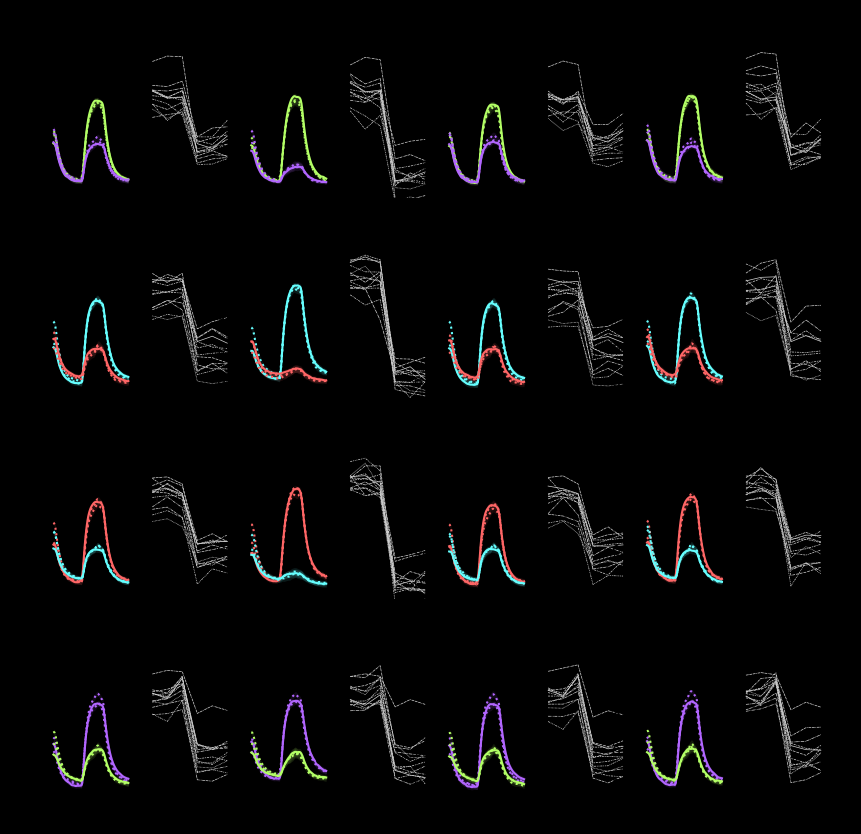

In [4]:
paths =[
 r"C:\Data\Imaging\260415_overlap\fish3",r"C:\Data\Imaging\260415_overlap\fish3_2",
r"C:\Data\Imaging\260415_overlap\fish4", r"C:\Data\Imaging\260415_overlap\fish4_2",
     r"C:\Data\Imaging\260415_overlap\fish6", r"C:\Data\Imaging\260415_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish1", r"C:\Data\Imaging\260425_overlap\fish1_2",
r"C:\Data\Imaging\260425_overlap\fish2",r"C:\Data\Imaging\260425_overlap\fish2_2",
r"C:\Data\Imaging\260425_overlap\fish3",r"C:\Data\Imaging\260425_overlap\fish3_2",
r"C:\Data\Imaging\260425_overlap\fish5",r"C:\Data\Imaging\260425_overlap\fish5_2",
 r"C:\Data\Imaging\260425_overlap\fish6", r"C:\Data\Imaging\260425_overlap\fish6_2",
r"C:\Data\Imaging\260425_overlap\fish7",r"C:\Data\Imaging\260425_overlap\fish7_2",
r"C:\Data\Imaging\260425_overlap\fish8",r"C:\Data\Imaging\260425_overlap\fish8_2",
r"C:\Data\Imaging\260425_overlap\fish9", r"C:\Data\Imaging\260425_overlap\fish9_2",
 r"C:\Data\Imaging\260425_overlap\fish10", r"C:\Data\Imaging\260425_overlap\fish10_2",
r"C:\Data\Imaging\260425_overlap\fish11", r"C:\Data\Imaging\260425_overlap\fish11_2",]

regions =  ['forebrain', 'hindbrain', 'tectum', 'pretectum']
f_dict = {r: [] for r in regions}
for r in regions:
    for path in paths:
        f = pd.read_csv(path + f'//analyze_results//grating_{r}neurons.csv', index_col = 0)
        f.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
        f_dict[r].append(f)
    f_dict[r] = pd.concat(f_dict[r]).reset_index(drop = True)
fig = plot_line(f_dict)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//grating_supression_enhancement.svg")
plt.show()
plt.close()

In [20]:
def plot_line_efference(f_dict):
    omr_stims = ['forward', 'left', 'right', 'backward']
    fig, ax = plt.subplots(len(omr_stims), len(f_dict) * 2, figsize=(10, 10), facecolor = 'black')
    for r_n, (r, f) in enumerate(f_dict.items()):
        for stim_n, stim in enumerate(omr_stims):
            ax_line = ax[stim_n, r_n * 2]
            ax_scatter = ax[stim_n, r_n * 2 + 1]
            ax_line.set_title(f"{r} {stim}")

            f_max = []
            opp_stim = utils.angles_omr[(utils.omr_angles[stim] + 180)%360]
            for g, (grating, color) in enumerate(zip([stim, opp_stim], [utils.omr_colors[stim], utils.omr_colors[opp_stim]])):
                for d, (dot, linestyle) in enumerate(zip([None, 'dot_l', 'dot_r'], ['-', ':', ':'])):
                    if dot == None:
                        real_stim = grating
                    else:
                        real_stim =  str([dot, grating])
                    for m, motor in enumerate([True, False]):
                        #get f
                        f_stim = f[(f.barred == stim) & (f.stim == real_stim) & (f.gratingresponse == motor)].drop(['barred', 'stim', 'gratingresponse'], axis=1)
                        f_stim = f_stim.groupby('real_fish_id').mean()
                        f_mean = np.nanmean(f_stim, axis=0)
                        f_sem = f_stim.sem(axis=0)  #/ np.sqrt(f_stim.shape[0])
                        if not motor: actualcolor = 'grey'
                        else: actualcolor = color
                        ax_line.plot(f_mean, c=actualcolor, linestyle = linestyle)
                        ax_line.fill_between(np.arange(len(f_mean)), f_mean - f_sem, f_mean + f_sem, color=actualcolor, alpha=0.1,linewidth=0)
                        ax_line.set_ylim([0.15, 0.65])
                        ax_line.set_xticks([])
                        ax_line.set_xticklabels([])

                        f_max.append(list(f_stim.iloc[:, 40:].max(axis = 1)))
            f_max = pd.DataFrame(np.array(f_max).T, columns=['omr', 'omr_m', 'omr_dotl', 'omr_dotl_m', 'omr_dotr', 'omr_dotr_m', 'opp', 'opp_m', 'opp_dotl', 'opp_dotl_m', 'opp_dotr', 'opp_dotr_m'])
            sns.lineplot(f_max.T, ax = ax_scatter, c="dimgrey", linestyle="-",  legend = False, linewidth = .5)
            #sns.lineplot(f_max.mean(), ax = ax_scatter, c="dimgrey", linestyle="-",  legend = False, linewidth = .5)
            for line in ax_scatter.lines:
                line.set_color('lightgrey')
            ax_scatter.set_ylim([0.2, .6])
            ax_scatter.set_facecolor('black')
            ax_line.set_facecolor('black')

    return fig

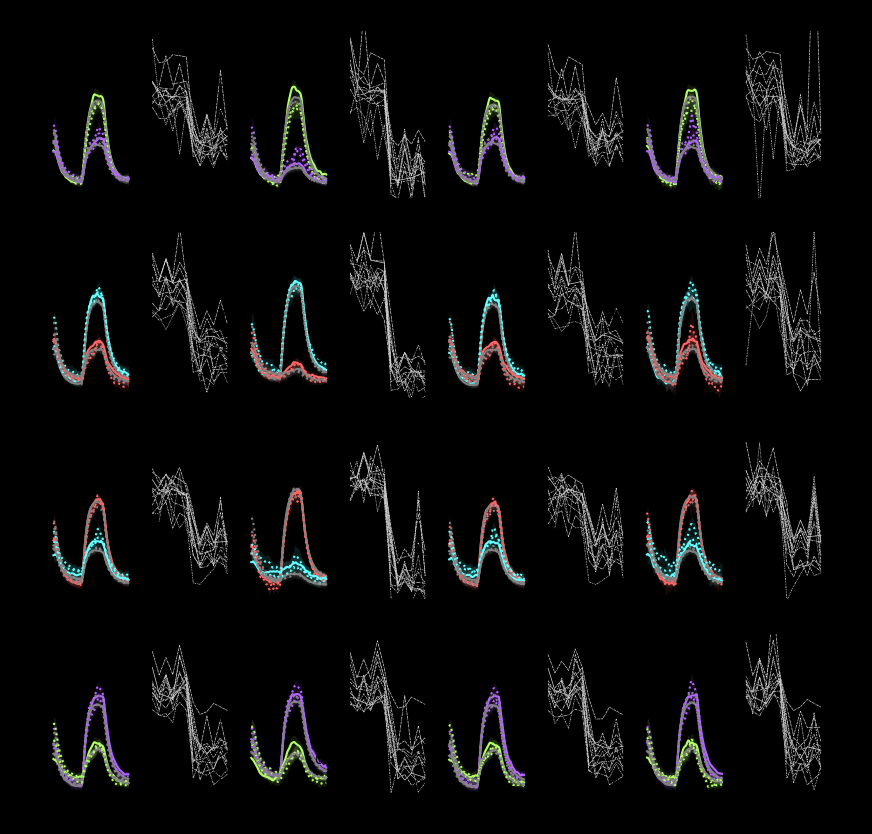

In [22]:
regions =  ['forebrain', 'hindbrain', 'tectum', 'pretectum']
f_dict = {r: [] for r in regions}
for r in regions:
    for path in paths:
        f = pd.read_csv(path + f'//analyze_results//gratingefferenceh_{r}neurons.csv', index_col = 0)
        f.loc[:, 'real_fish_id'] = str(path).split("Imaging")[1].split("_")[0]+str(path).split("Imaging")[1].split("_")[1]
        f_dict[r].append(f)
    f_dict[r] = pd.concat(f_dict[r]).reset_index(drop = True)
fig = plot_line_efference(f_dict)
plt.savefig(r"C:\Data\Imaging\260425_overlap\All_imaging//gratingefference_h_supression_enhancement.svg")
plt.show()
plt.close()

In [6]:
f_dict['forebrain'].columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '107', '108', '109', '110', '111', '112', 'barred', 'stim',
       'gratingresponse', 'real_fish_id'],
      dtype='object', length=117)